# Phase 1 — Zodiac Star Spectral Analysis
## Physics-Informed Spectral State Estimator

**Goal**: Independently analyse the stellar spectrum of every principal star across all 12 zodiac constellations.

**Pipeline per star**
```
Archive query (SDSS) or synthetic fallback
        ↓
Preprocessing  (DenoiseNetPhysics or Savitzky-Golay)
        ↓
Spectral Transformation  (FFT / optical-frequency domain)
        ↓
Peak Detection  (adapted from peak_assignment.py)
        ↓
Resonance Coherence Score  RC = Σ exp(-|fᵢ - (p/q)fⱼ|)
        ↓
Energy Bands   E_UV, E_VIS, E_IR, E_total = ∫F(λ)dλ
        ↓
Harmonic Families  (integer-ratio peak groupings)
        ↓
SQLite storage  →  CSV export
```

**Phase 2** (tensor energy model) is activated once spectral throughlines are identified here.

In [15]:
# ── Section 1: Install / check dependencies ──────────────────────────────────
# Run this cell once to install missing packages.
# Comment out after first successful run.

import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["astropy", "specutils", "astroquery", "scipy", "matplotlib"]
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        _pip(pkg)

print("✅ All dependencies present")

✅ All dependencies present


---
## Section 1 — Import Required Libraries

In [16]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110
import matplotlib.pyplot as plt
%matplotlib inline

# ── Repo-root path setup ──────────────────────────────────────────────────────
# This notebook lives in stellar_spectrospy/; repo root is one level up.
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Notebook's own directory
NB_DIR = Path(".").resolve()

# ── New Phase-1 modules ───────────────────────────────────────────────────────
from stellar_spectrospy.zodiac_targets      import (ZODIAC_STARS, get_all_stars,
                                                     get_stars_by_constellation,
                                                     get_star_by_name, summary_table)
from stellar_spectrospy.unified_signal_engine import SpectralStateEstimator
from stellar_spectrospy.spectral_database     import SpectralDatabase
from stellar_spectrospy.analysis_runner       import ZodiacRunner, SpectrumFetcher

# ── Confirm existing NMR modules load cleanly ────────────────────────────────
try:
    from nuclear_magnetic_resonance_spectrospy.nmr_function import compute_fft_spectrum
    from nuclear_magnetic_resonance_spectrospy.peak_assignment import ChemicalShiftDatabase
    print("✅ NMR modules imported")
except ImportError as e:
    print(f"⚠️  NMR module import warning (non-fatal): {e}")

from datetime import datetime
print(f"✅ Phase-1 modules loaded  |  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ NMR modules imported
✅ Phase-1 modules loaded  |  2026-02-21 19:55:52


---
## Section 2 — Define Initial Parameters

In [17]:
# ── Analysis configuration ────────────────────────────────────────────────────

CFG = {
    # Output paths (relative to NB_DIR)
    "cache_dir":           NB_DIR / "spectral_cache",
    "db_path":             NB_DIR / "spectral_results.db",
    "export_csv":          NB_DIR / "spectral_results.csv",
    "checkpoint_dir":      NB_DIR / "checkpoints",            # DenoiseNetPhysics .pth files

    # Spectrum fetching
    "sdss_radius_arcsec":  3.0,    # cone search radius for SDSS
    "use_ml_denoise":      False,  # set True if checkpoints are present

    # Peak detection
    "height_frac":         0.05,   # peak height relative to max
    "prominence_frac":     0.03,

    # Resonance coherence
    "rc_max_p":            6,
    "rc_max_q":            6,
    "rc_sigma":            1.0,    # same units as frequencies

    # Visualisation
    "plot_per_star":       True,   # set False for headless batch runs
    "figsize":             (16, 10),
}

# Physical constants (SI)
PLANCK_H       = 6.626e-34   # J·s
SPEED_OF_LIGHT = 2.998e8     # m/s

# Wavelength band boundaries (Angstroms)
BAND_UV  = (1000,  4000)
BAND_VIS = (4000,  7000)
BAND_IR  = (7000, 25000)

# Catalogue summary
print(summary_table())

                              ZODIAC STAR CATALOG                               
Constellation  Name                 Bayer    Type          Vmag  Dist(ly)
--------------------------------------------------------------------------------
Aries          Hamal                α Ari    K2III         2.00        66
               Sheratan             β Ari    A5V           2.64        59
               Mesarthim            γ Ari    A1pSi         3.88       164
               Botein               δ Ari    K2III         4.35       168
--------------------------------------------------------------------------------
Taurus         Aldebaran            α Tau    K5III         0.87        65
               Elnath               β Tau    B7III         1.65       131
               Alcyone              η Tau    B7IIIe        2.87       440
               Ain                  ε Tau    K0III         3.53       147
               Tianguan             ζ Tau    B4IIIpe       3.00       440
-----------------

---
## Section 3 — Build Core Logic
### 3a. Initialise Database and Runner

In [18]:
runner = ZodiacRunner(
    cache_dir=CFG["cache_dir"],
    db_path=CFG["db_path"],
    checkpoint_dir=CFG["checkpoint_dir"],
    device="cpu",
)

runner.print_status()
print(f"\nTotal stars in catalog: {len(get_all_stars())}")
print(f"Constellations        : {len(ZODIAC_STARS)}")

SpectralDatabase  path=C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.db
  Stars stored    : 5
  Metric records  : 5
  Constellations  : 1

Total stars in catalog: 54
Constellations        : 12


### 3b. Single-Star Demo (Aldebaran — α Tauri)

In [19]:
# ── Demo: single star end-to-end ──────────────────────────────────────────────

DEMO_STAR_NAME = "Aldebaran"           # change to any name in zodiac_targets.py

star  = get_star_by_name(DEMO_STAR_NAME)
fetch = SpectrumFetcher(CFG["cache_dir"])

# Fetch (SDSS archive → synthetic fallback if offline)
wl, flux = fetch.fetch(star)

# Build estimator
est = SpectralStateEstimator(
    mode="stellar",
    checkpoint_dir=CFG["checkpoint_dir"],
    device="cpu",
)
est.load_spectrum(wl, flux, name=star.name)

# Run full pipeline
metrics = est.analyse(
    use_ml_denoise=CFG["use_ml_denoise"],
    height_frac=CFG["height_frac"],
    prominence_frac=CFG["prominence_frac"],
)

# Harmonic families
families = est.find_harmonic_families()
metrics["harmonic_families"] = families

print("\n" + "─" * 60)
print(est.summary())

  [Cache] Aldebaran
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aldebaran'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4

────────────────────────────────────────────────────────────
SpectralStateEstimator — Aldebaran
  Mode            : stellar
  Points          : 4096
  Peaks detected  : 4
  Coherence (RC)  : 0.0
  e_uv            : 2.0331018879304035e-12
  e_vis           : 2.6140238082882575e-11
  e_ir            : 2.519461769431653e-11
  e_total         : 5.3367957746390595e-11


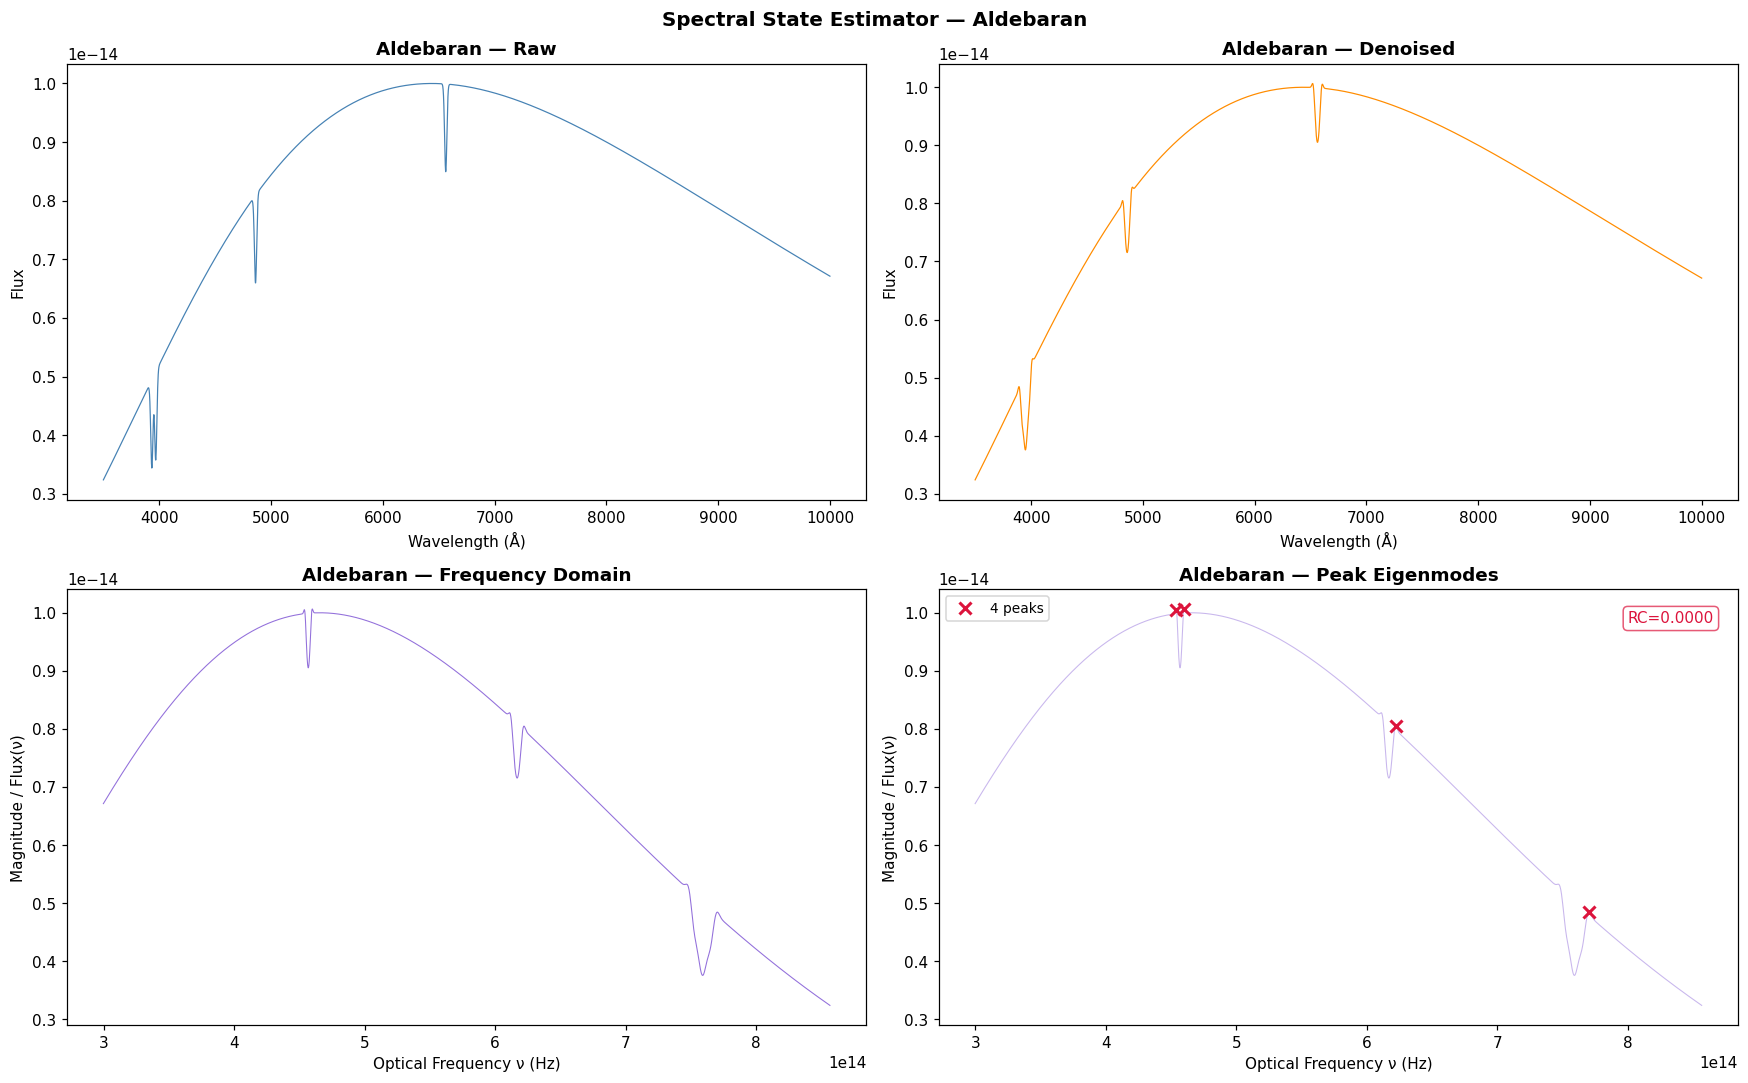

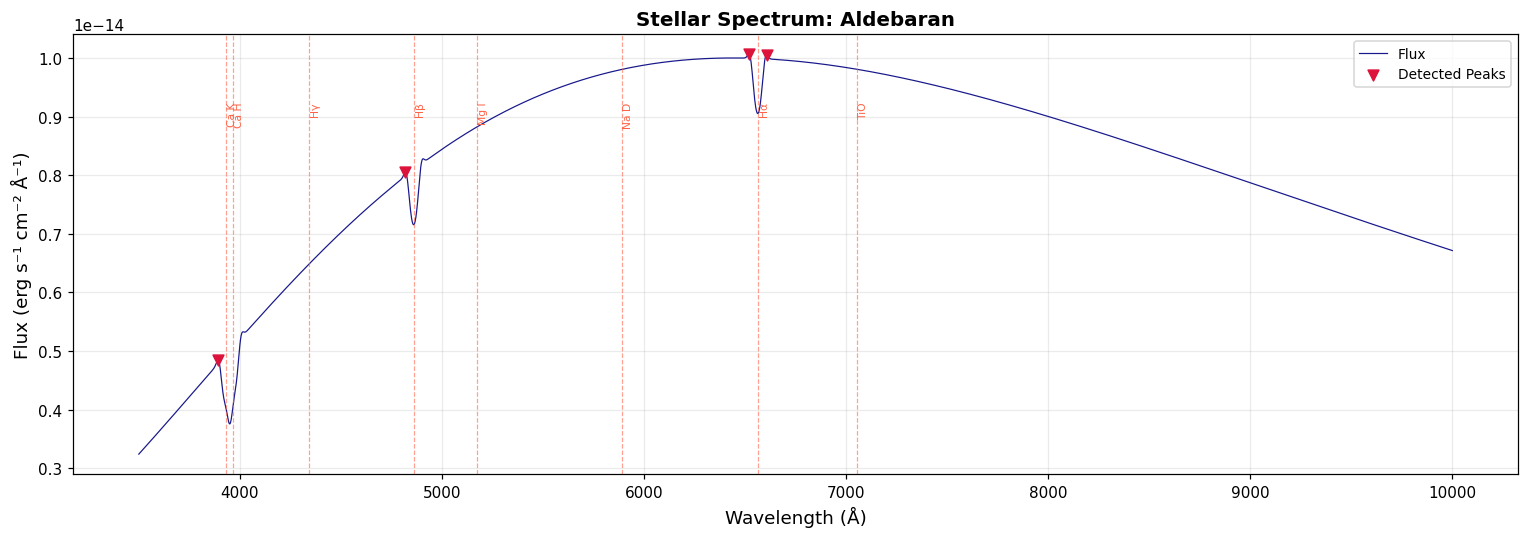

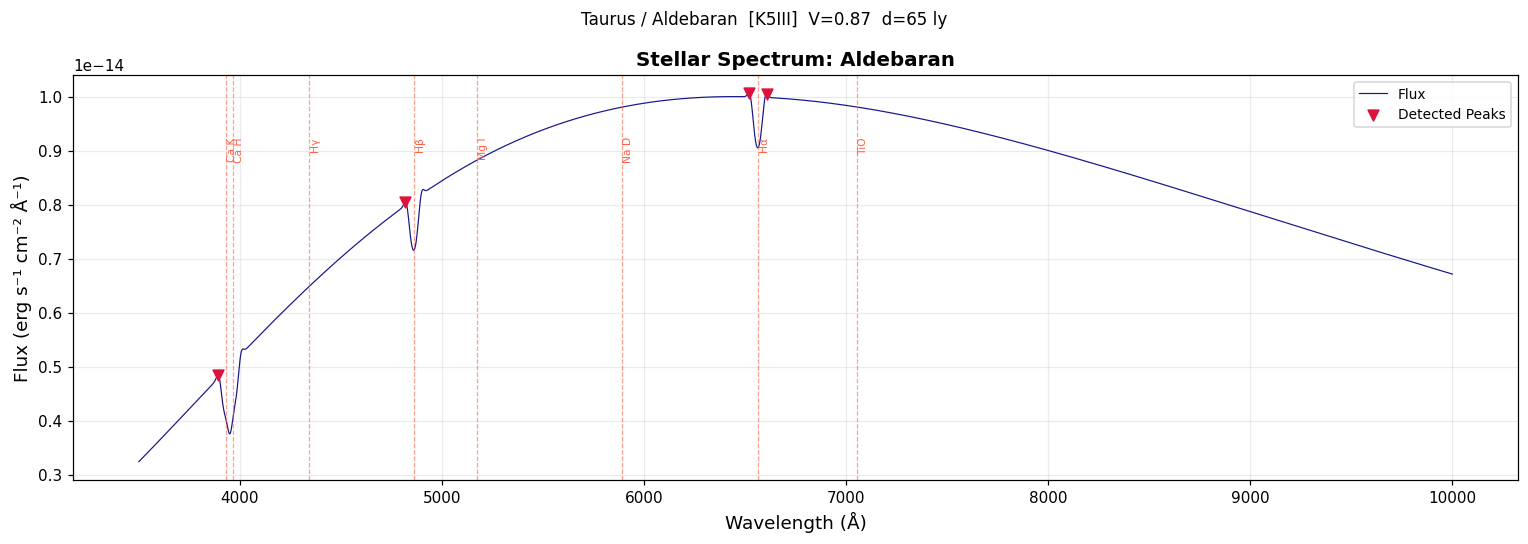

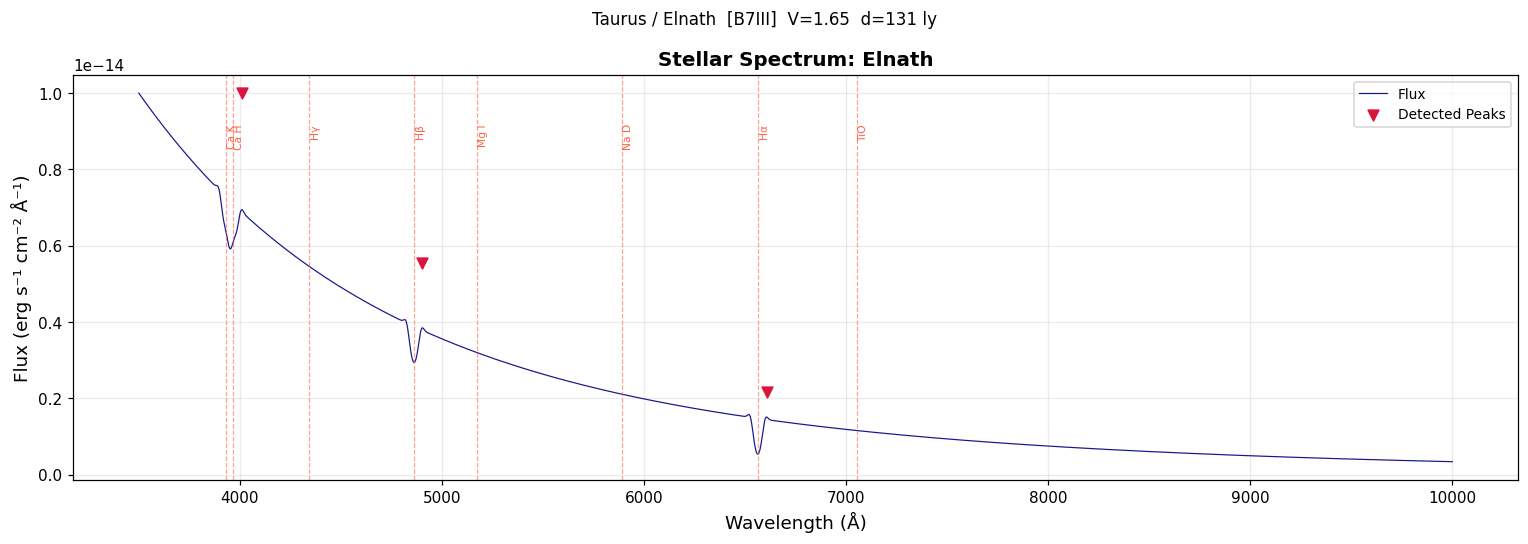

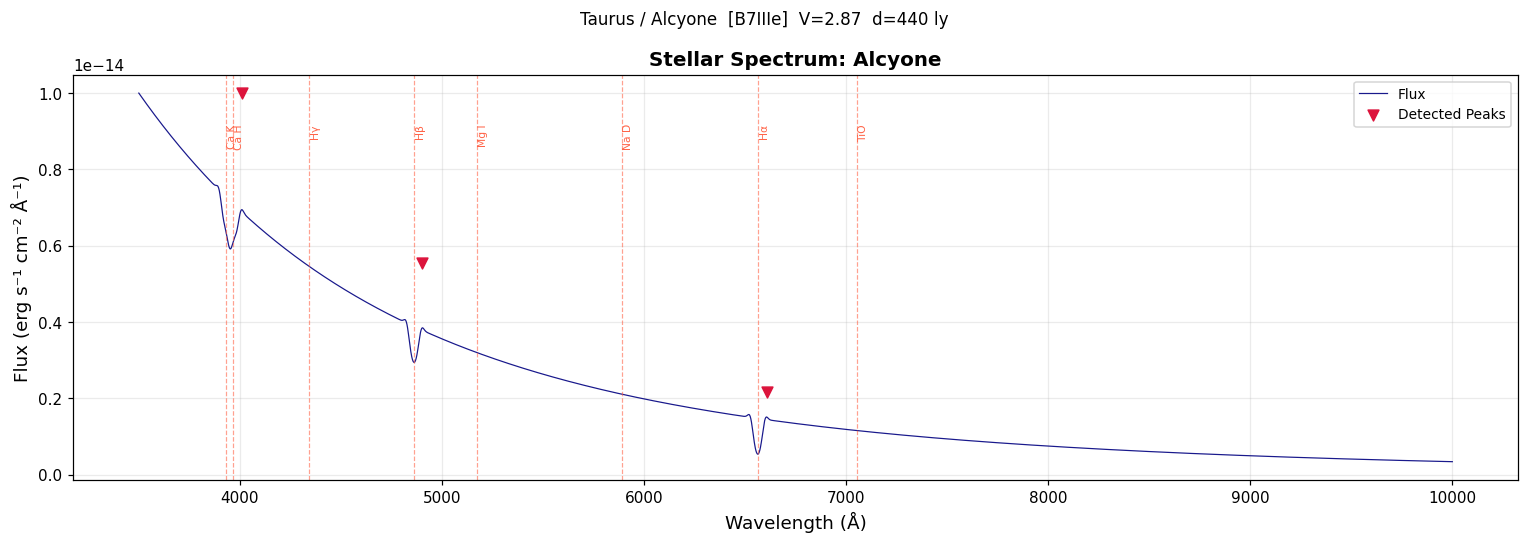

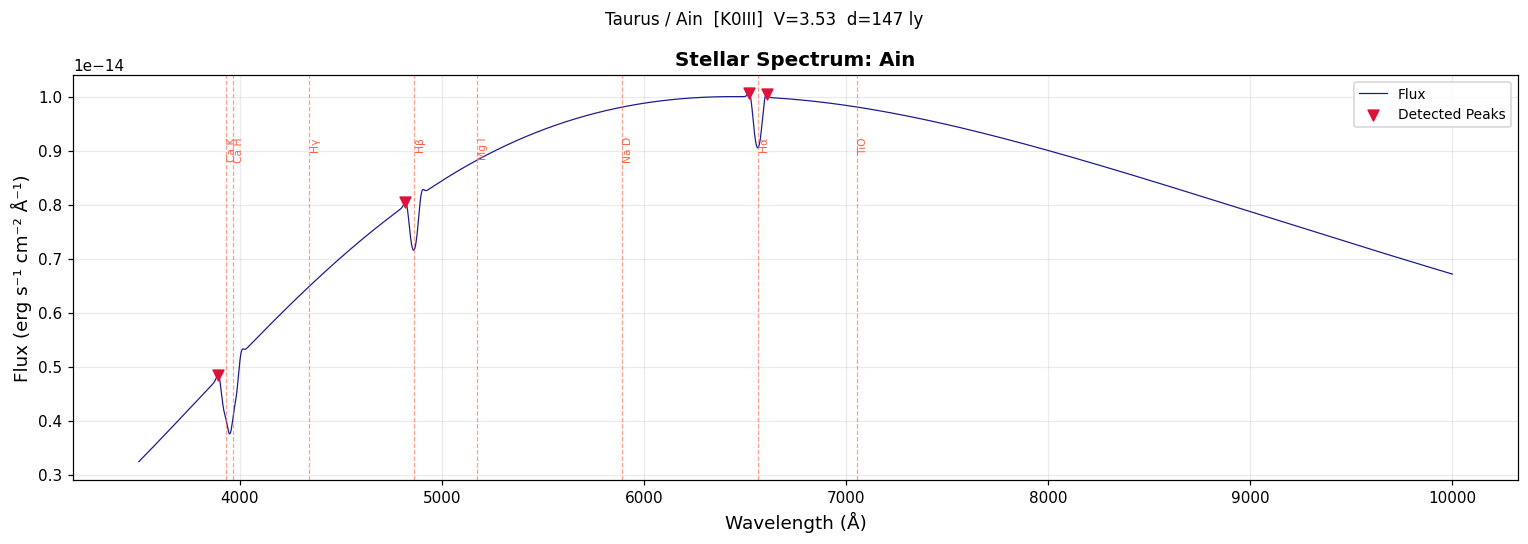

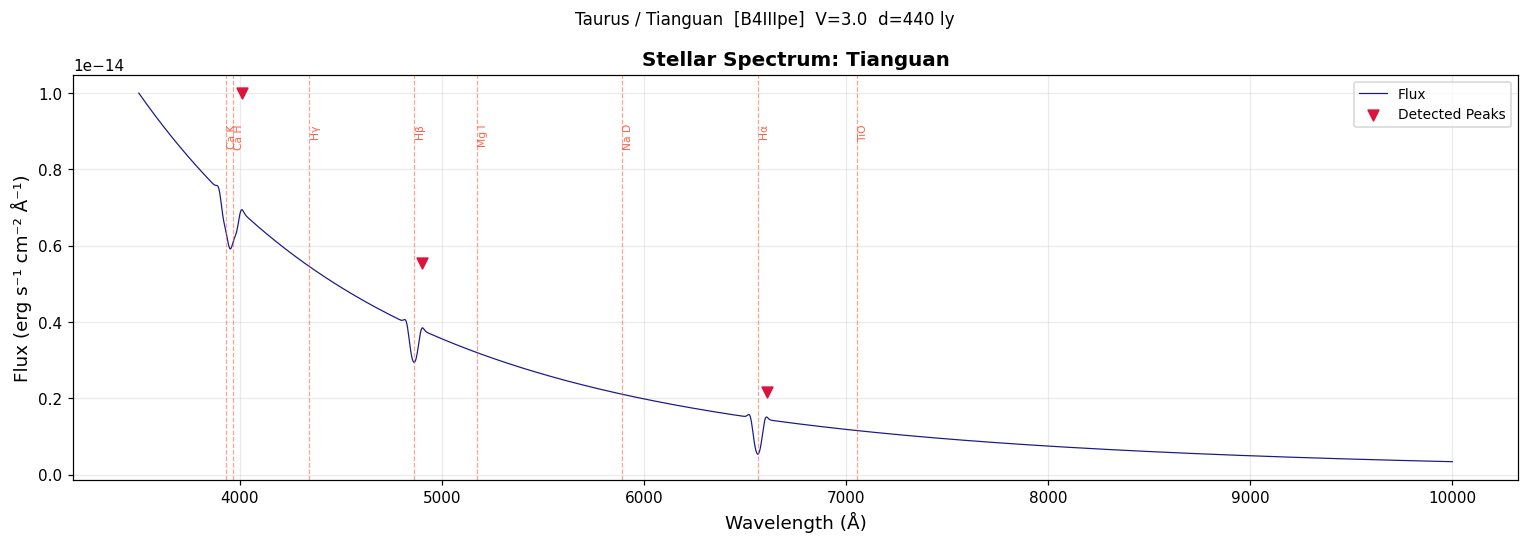

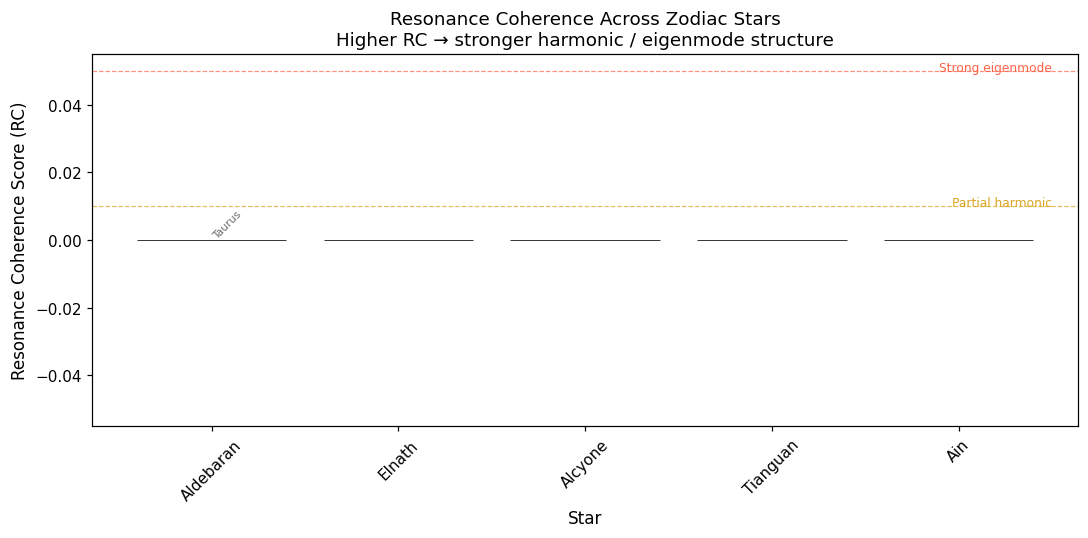

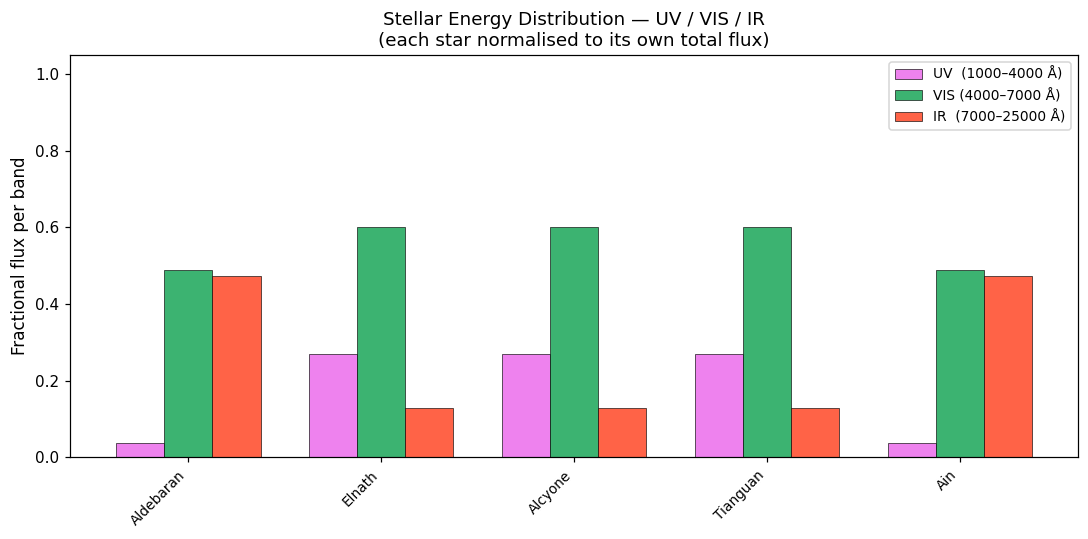

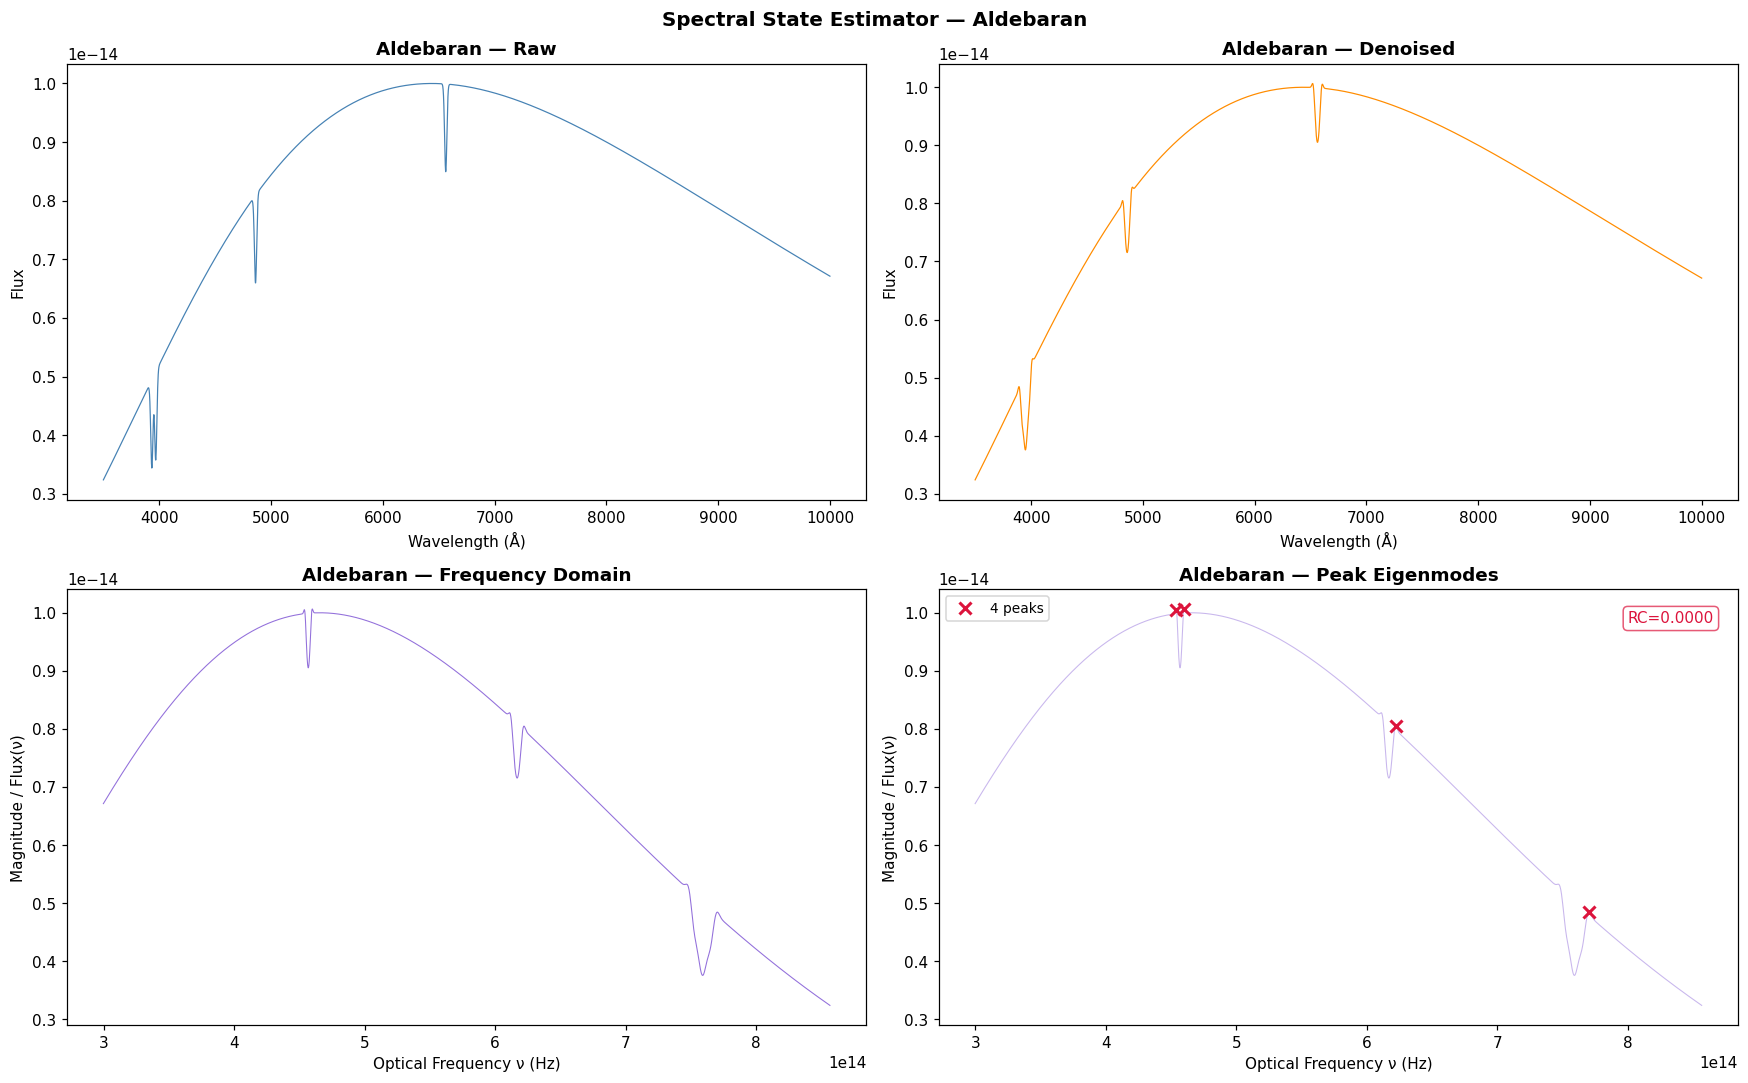

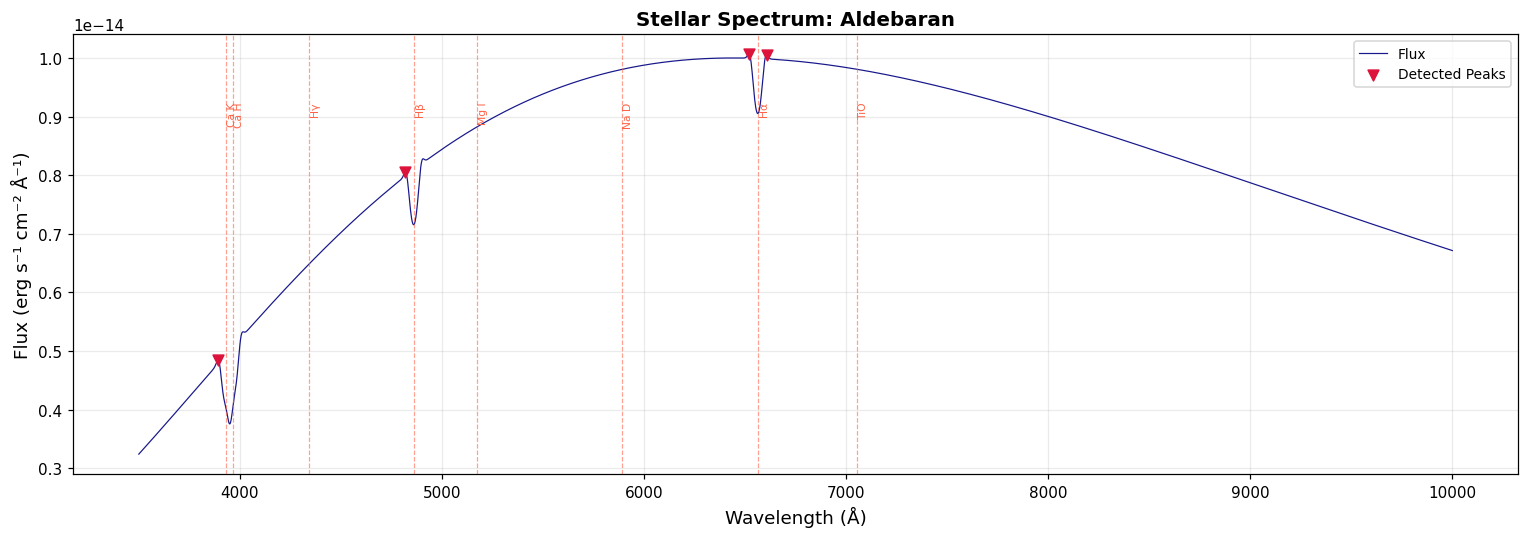

In [20]:
# ── Visualise 4-panel pipeline plot ───────────────────────────────────────────
matplotlib.rcParams["figure.dpi"] = 110
if CFG["plot_per_star"]:
    fig = est.plot_pipeline(figsize=CFG["figsize"], show=False)
    plt.show()

# ── Calibrated wavelength spectrum ────────────────────────────────────────────
if CFG["plot_per_star"]:
    fig2 = est.plot_stellar_wavelength_spectrum(show=False)
    plt.show()

### 3c. Resonance Coherence Score — Anatomy

The **Resonance Coherence (RC)** score quantifies how well the detected peak frequencies
align to harmonic (small-integer) ratios, characteristic of stellar eigenmode families.

$$RC = \sum_{i \neq j} \sum_{p=1}^{P} \sum_{q=1}^{Q} \exp\!\left(-\frac{|f_i - \frac{p}{q} f_j|}{\sigma}\right)$$

| Score range | Interpretation |
|---|---|
| RC ≈ 0 | Incoherent / noise-dominated |
| RC 0.01 – 0.10 | Partial harmonic content |
| RC > 0.10 | Strong eigenmode family structure |

### 3d. Single Constellation Analysis Loop

Change `TARGET_CONSTELLATION` to walk through any of the 12 zodiac constellations.
Run `runner.run_all()` in the next section for the full survey.

In [21]:
# ── Constellation analysis ────────────────────────────────────────────────────

TARGET_CONSTELLATION = "Taurus"     # ← change to any zodiac constellation

df_const = runner.run_constellation(
    TARGET_CONSTELLATION,
    max_stars=None,                 # None = all stars in constellation
    use_ml_denoise=CFG["use_ml_denoise"],
    verbose=True,
)

print(f"\n{'='*60}")
print(f"Results for {TARGET_CONSTELLATION}")
print(df_const)


  Constellation: Taurus  (5 stars)

────────────────────────────────────────────────────────────
  Taurus / Aldebaran  [K5III]
  [Cache] Aldebaran
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aldebaran'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4
SpectralStateEstimator — Aldebaran
  Mode            : stellar
  Points          : 4096
  Peaks detected  : 4
  Coherence (RC)  : 0.0
  e_uv            : 2.0331018879304035e-12
  e_vis           : 2.6140238082882575e-11
  e_ir            : 2.519461769431653e-11
  e_total         : 5.3367957746390595e-11

────────────────────────────────────────────────────────────
  Taurus / Elnath  [B7III]
  [Cache] Elnath
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Elnath'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
SpectralStateEstimator — Elnath
  Mode            : stellar
  Points          : 4096
  Peaks detected  :

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aldebaran'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4


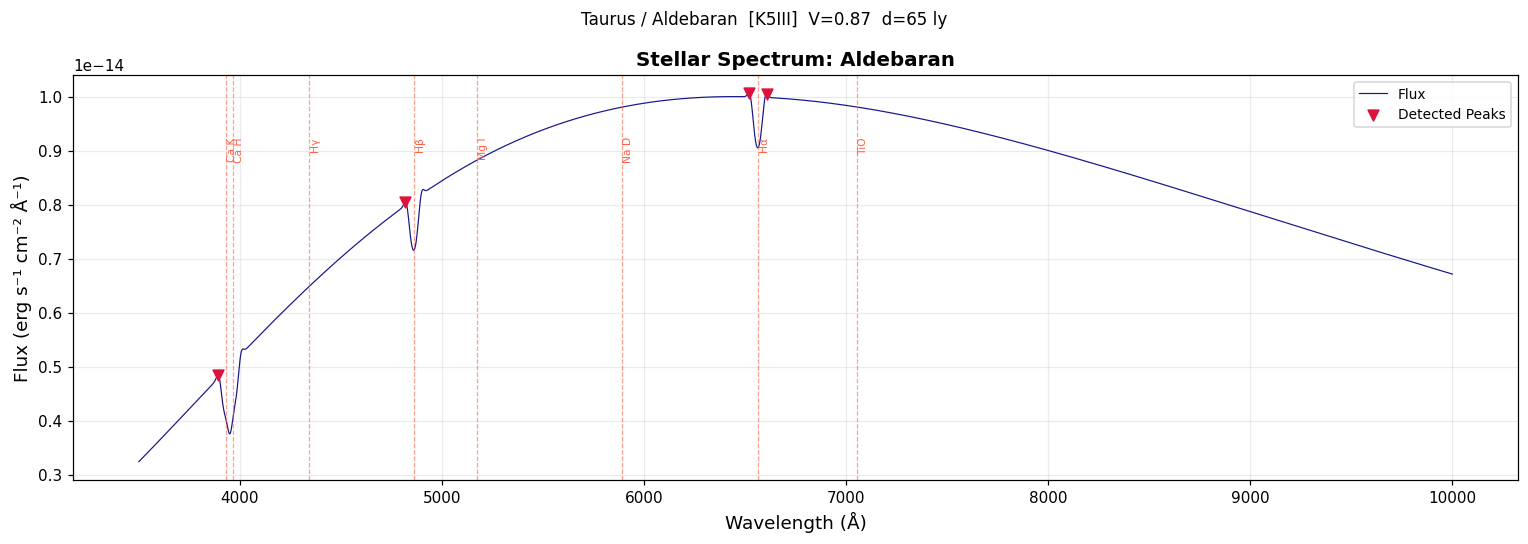

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Elnath'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3


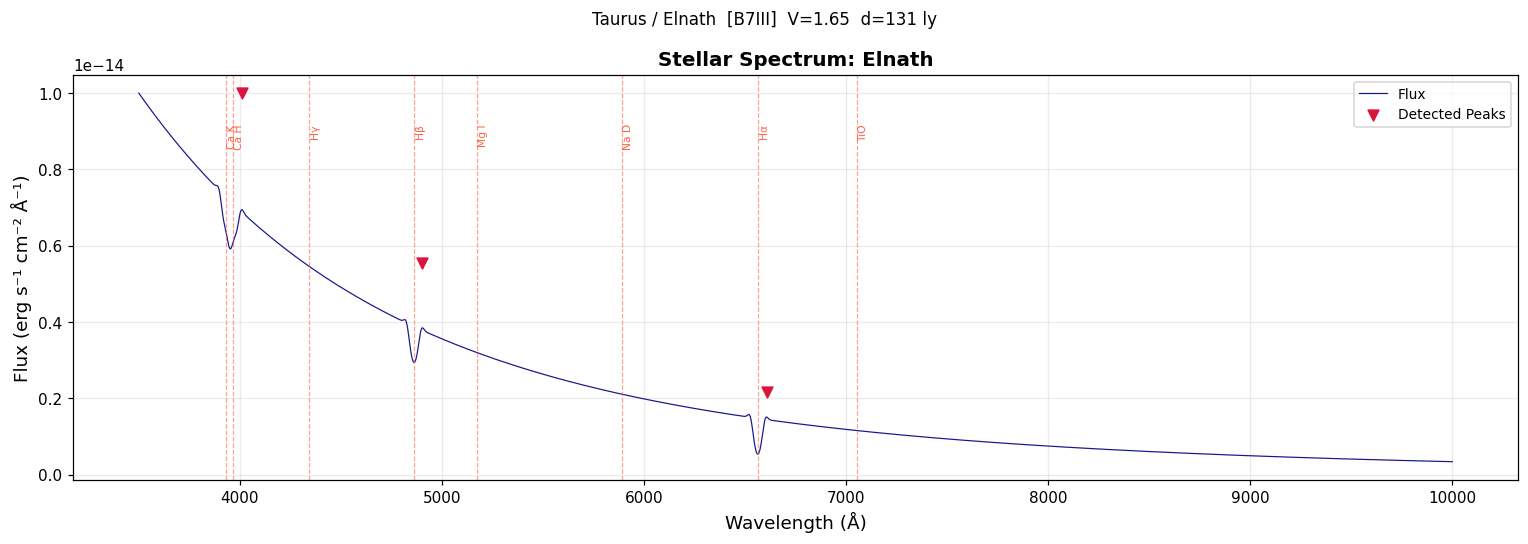

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Alcyone'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3


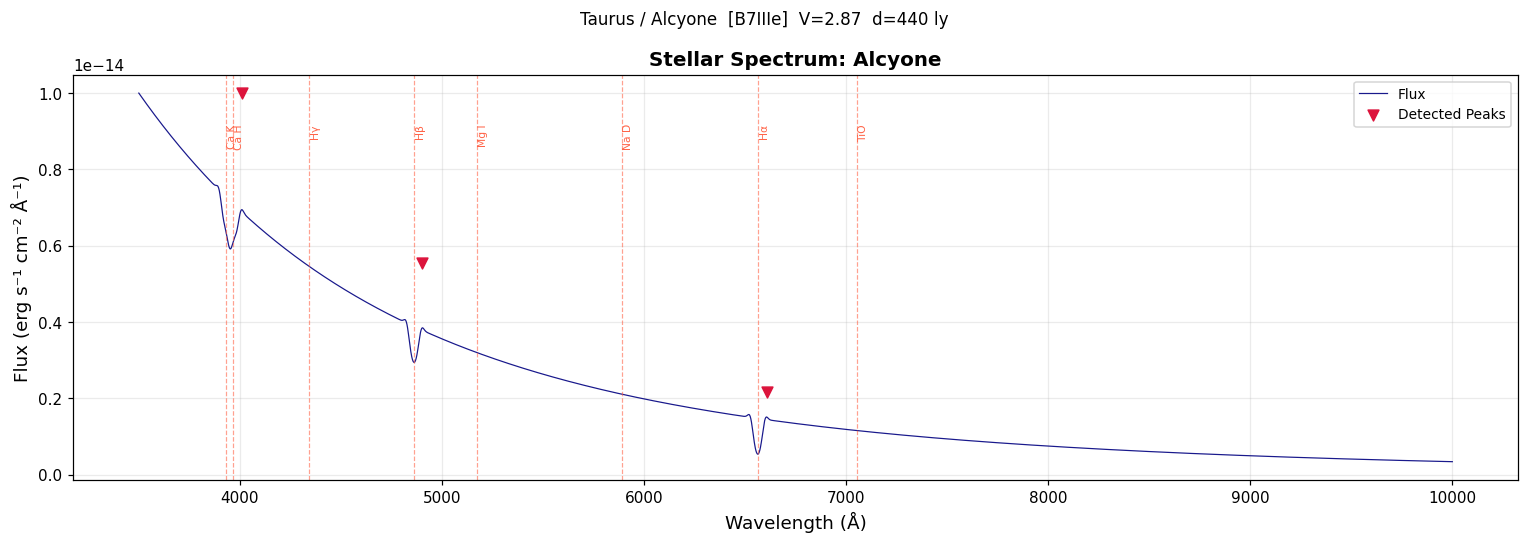

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Ain'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4


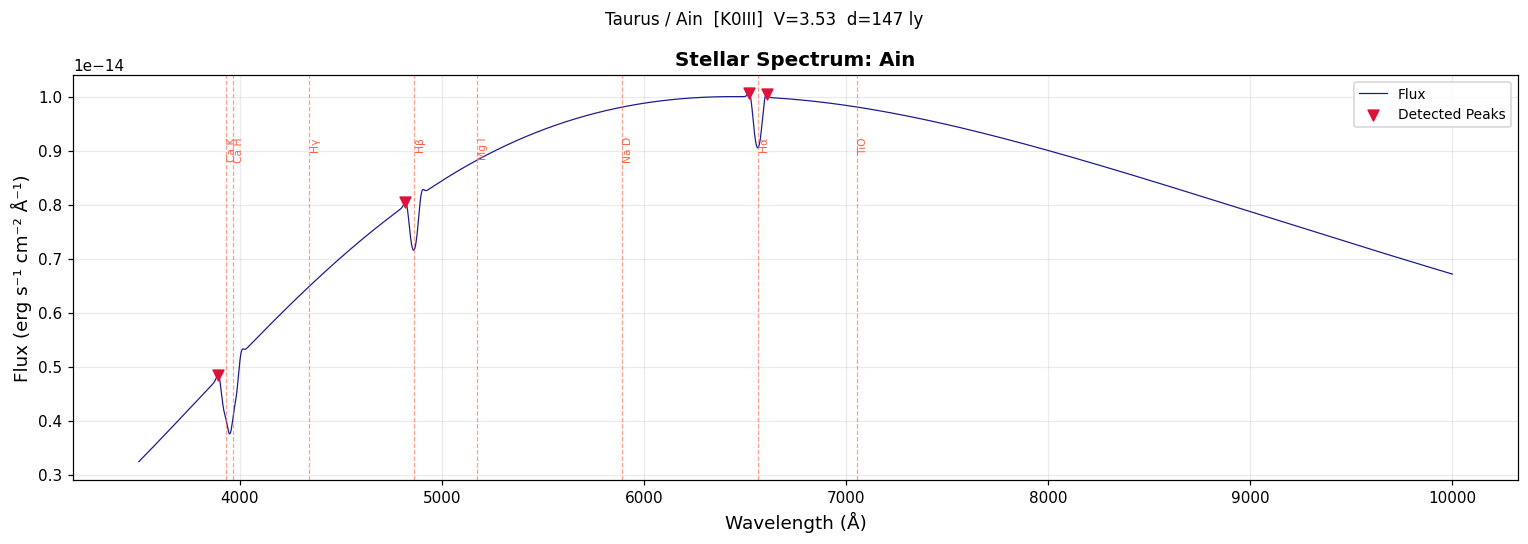

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Tianguan'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3


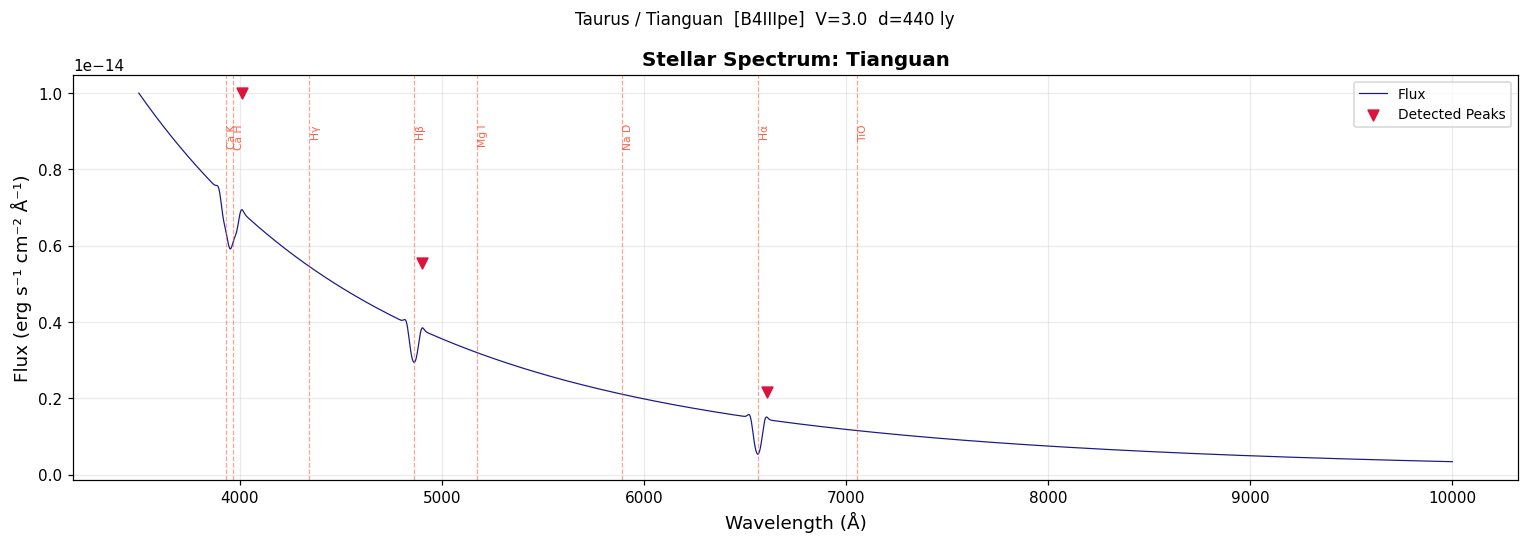

In [22]:
# ── Optional: visualise every star in the constellation ───────────────────────

if CFG["plot_per_star"]:
    stars_in_const = get_stars_by_constellation(TARGET_CONSTELLATION)
    for star in stars_in_const:
        cached = runner.fetcher.load_from_cache(star.name)
        if cached is None:
            continue
        wl_s, flux_s = cached

        est_s = SpectralStateEstimator(mode="stellar")
        est_s.load_spectrum(wl_s, flux_s, name=star.name)
        est_s.preprocess(use_ml=False)
        est_s.transform()
        est_s.detect_peaks()
        est_s.resonance_coherence()
        est_s.compute_energy_metrics()

        fig = est_s.plot_stellar_wavelength_spectrum(show=False)
        fig.suptitle(
            f"{star.constellation} / {star.name}  [{star.spectral_type}]  "
            f"V={star.vmag}  d={star.dist_ly} ly",
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()

### 3e. Full Zodiac Survey (all 12 constellations)

⚠️ **This cell makes live SDSS archive queries** (or synthetic fallback if offline).  
Results are cached to `spectral_cache/` so subsequent runs are fast.  
Estimated runtime: 5 – 15 min for full survey (network dependent).

In [23]:
# ── Full survey ───────────────────────────────────────────────────────────────
# Set RUN_FULL = True to execute the complete zodiac run.

RUN_FULL = False    # ← set to True when ready for the full survey

if RUN_FULL:
    df_all = runner.run_all(
        max_stars_per_const=None,
        use_ml_denoise=CFG["use_ml_denoise"],
        verbose=True,
    )
    csv_path = runner.export_csv(CFG["export_csv"])
    print(f"\n✅ Survey complete.  Results → {csv_path}")
else:
    print("RUN_FULL = False  — set to True to run the complete zodiac survey.")

RUN_FULL = False  — set to True to run the complete zodiac survey.


---
## Section 4 — Run and Validate Output

### 4a. Database Status & Per-Star Metrics

In [24]:
# ── Database status ───────────────────────────────────────────────────────────
runner.print_status()

# ── Pull all stored results ────────────────────────────────────────────────────
df_results = runner.summary_dataframe()
print("\nAll stored results:")
print(df_results)

SpectralDatabase  path=C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.db
  Stars stored    : 5
  Metric records  : 10
  Constellations  : 1

All stored results:
  object_name constellation spectral_type  vmag  coherence_score  \
0   Aldebaran        Taurus         K5III  0.87              0.0   
1   Aldebaran        Taurus         K5III  0.87              0.0   
2      Elnath        Taurus         B7III  1.65              0.0   
3      Elnath        Taurus         B7III  1.65              0.0   
4     Alcyone        Taurus        B7IIIe  2.87              0.0   
5     Alcyone        Taurus        B7IIIe  2.87              0.0   
6    Tianguan        Taurus       B4IIIpe  3.00              0.0   
7    Tianguan        Taurus       B4IIIpe  3.00              0.0   
8         Ain        Taurus         K0III  3.53              0.0   
9         Ain        Taurus         K0III  3.53              0.0   

        e_total          e_uv         e_vis          e_ir  \
0  5.3

### 4b. Resonance Coherence Score — Cross-Constellation Comparison

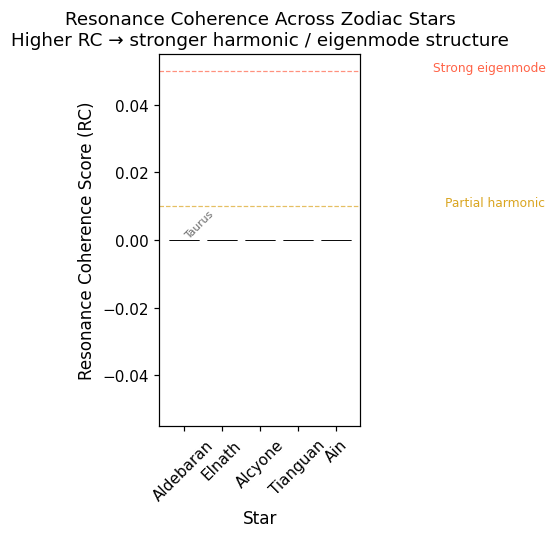

Stars plotted: 10


In [25]:
try:
    import pandas as pd
    _pd = True
except ImportError:
    _pd = False

data = runner.db.query_all()
if not data:
    print("No results yet — run a constellation analysis above first.")
else:
    names  = [r["object_name"]    for r in data if r.get("coherence_score") is not None]
    consts = [r["constellation"]  for r in data if r.get("coherence_score") is not None]
    scores = [r["coherence_score"]for r in data if r.get("coherence_score") is not None]

    if not scores:
        print("No coherence scores computed yet.")
    else:
        fig, ax = plt.subplots(figsize=(max(10, len(names)*0.5), 5))
        colors = plt.cm.tab20(np.linspace(0, 1, len(scores)))
        bars = ax.bar(names, scores, color=colors, edgecolor="k", linewidth=0.5)
        ax.set_xlabel("Star", fontsize=11)
        ax.set_ylabel("Resonance Coherence Score (RC)", fontsize=11)
        ax.set_title(
            "Resonance Coherence Across Zodiac Stars\n"
            "Higher RC → stronger harmonic / eigenmode structure",
            fontsize=12,
        )
        ax.tick_params(axis="x", rotation=45)

        # Annotate constellation labels
        prev_const = None
        for i, (name, bar_, const) in enumerate(zip(names, bars, consts)):
            if const != prev_const:
                ax.text(
                    bar_.get_x() + bar_.get_width() / 2,
                    bar_.get_height() + max(scores) * 0.01,
                    const,
                    ha="left", va="bottom", fontsize=7, color="dimgray",
                    rotation=45,
                )
                prev_const = const

        # Reference lines
        for thresh, label, color in [
            (0.01, "Partial harmonic", "goldenrod"),
            (0.05, "Strong eigenmode", "tomato"),
        ]:
            ax.axhline(thresh, linestyle="--", linewidth=0.8, color=color, alpha=0.7)
            ax.text(len(scores) - 0.5, thresh + max(scores) * 0.005,
                    label, ha="right", fontsize=8, color=color)

        plt.tight_layout()
        plt.show()
        print(f"Stars plotted: {len(scores)}")

### 4c. Stellar Energy Band Comparison (UV  /  VIS  /  IR)

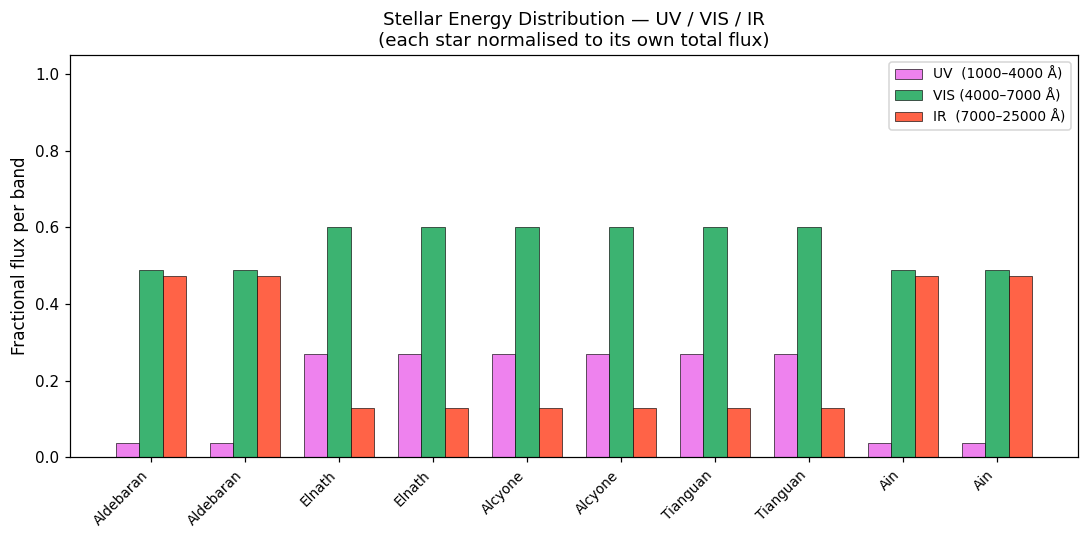

Stars plotted: 10


In [26]:
data = runner.db.query_all()
valid = [r for r in data if r.get("e_total") is not None]

if not valid:
    print("No energy metrics yet — run constellation analysis first.")
else:
    names = [r["object_name"] for r in valid]
    e_uv  = np.array([r.get("e_uv")  or 0 for r in valid])
    e_vis = np.array([r.get("e_vis") or 0 for r in valid])
    e_ir  = np.array([r.get("e_ir")  or 0 for r in valid])
    e_tot = np.array([r.get("e_total") or 0 for r in valid])

    # Normalise each star to its own total for comparison
    norm = np.where(e_tot == 0, 1.0, e_tot)
    uv_frac  = e_uv  / norm
    vis_frac = e_vis / norm
    ir_frac  = e_ir  / norm

    x = np.arange(len(names))
    w = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.6), 5))
    ax.bar(x - w,   uv_frac,  w, label="UV  (1000–4000 Å)",  color="violet",    edgecolor="k", linewidth=0.4)
    ax.bar(x,       vis_frac, w, label="VIS (4000–7000 Å)", color="mediumseagreen", edgecolor="k", linewidth=0.4)
    ax.bar(x + w,   ir_frac,  w, label="IR  (7000–25000 Å)", color="tomato",    edgecolor="k", linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Fractional flux per band", fontsize=11)
    ax.set_title(
        "Stellar Energy Distribution — UV / VIS / IR\n"
        "(each star normalised to its own total flux)",
        fontsize=12,
    )
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    print(f"Stars plotted: {len(names)}")

### 4d. Harmonic Family Structure

In [27]:
import json

# Re-run estimator on demo star to inspect harmonic structure
demo_cached = runner.fetcher.load_from_cache(DEMO_STAR_NAME)
if demo_cached:
    wl_d, flux_d = demo_cached
    est_h = SpectralStateEstimator(mode="stellar")
    est_h.load_spectrum(wl_d, flux_d, name=DEMO_STAR_NAME)
    est_h.preprocess(use_ml=False)
    est_h.transform()
    est_h.detect_peaks()
    families = est_h.find_harmonic_families()
    rc = est_h.resonance_coherence()

    print(f"\n{DEMO_STAR_NAME}  —  Harmonic Families  (RC = {rc:.5f})")
    print(f"{'─'*50}")
    if families:
        for i, fam in enumerate(families, 1):
            ratios = [f / fam[0] for f in fam]
            print(
                f"  Family {i:>2}: "
                + "  ".join(f"{f:.3e} Hz (×{r:.2f})" for f, r in zip(fam, ratios))
            )
    else:
        print("  No harmonic families detected")

    # Plot harmonic family comb
    if families:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(est_h._fft_freqs, est_h._fft_mag, linewidth=0.7,
                color="mediumpurple", alpha=0.6, label="Spectrum")
        cmap = plt.cm.tab10
        for i, fam in enumerate(families):
            color = cmap(i % 10)
            for f in fam:
                idx = np.argmin(np.abs(est_h._fft_freqs - f))
                ax.axvline(f, color=color, linewidth=1.2, alpha=0.8)
                ax.plot(f, est_h._fft_mag[idx], "o", color=color,
                        ms=6, label=f"Family {i+1}" if f == fam[0] else "")
        ax.set_xlabel("Optical Frequency ν (Hz)")
        ax.set_ylabel("Flux(ν)")
        ax.set_title(f"{DEMO_STAR_NAME} — Harmonic Family Comb (RC={rc:.5f})")
        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print(f"No cached spectrum for {DEMO_STAR_NAME} — run the demo cell first.")

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aldebaran'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4

Aldebaran  —  Harmonic Families  (RC = 0.00000)
──────────────────────────────────────────────────
  No harmonic families detected


### 4e. Export Results & Phase-2 Readiness Check

In [28]:
# ── Export CSV ────────────────────────────────────────────────────────────────
csv_out = runner.export_csv(CFG["export_csv"])
print(f"Results exported → {csv_out}\n")

# ── Phase-2 readiness check ───────────────────────────────────────────────────
from stellar_spectrospy.tensor_analysis import check_phase2_readiness
is_ready = check_phase2_readiness(str(CFG["db_path"]))

if is_ready:
    print("\n🌟  Phase-2 is ready to activate!")
    print("    Open phase2_energy_tensor.ipynb to begin tensor construction.")
else:
    remaining = runner.db.query_all()
    n_valid   = sum(1 for r in remaining if r.get("e_total") is not None)
    print(f"\n⏳  Phase-2 not yet unlocked.")
    print(f"    Stars with energy metrics: {n_valid} / 10 required.")
    print(f"    Run more constellation analyses above to continue.")

Exported 10 records → C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.csv
Results exported → C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.csv

Phase-2 readiness: 10 stars with metrics (READY)

🌟  Phase-2 is ready to activate!
    Open phase2_energy_tensor.ipynb to begin tensor construction.


---
## Phase-2 Preview (Stub — Do Not Execute Until Phase-1 Complete)

When ≥10 stars are analysed, Phase-2 activates the energy tensor framework:

```python
# ── Phase 2 activation (run in phase2_energy_tensor.ipynb) ──────────────────
from stellar_spectrospy.stellar_energy_model import StellarEnergyDatabase
from stellar_spectrospy.planetary_model      import SolarSystemModel
from stellar_spectrospy.tensor_analysis      import EnergyTensor

# Build stellar energy matrix from Phase-1 results
energy_db = StellarEnergyDatabase.from_phase1(phase1_db)
S_matrix, star_names = energy_db.energy_matrix()   # (N_stars, 4)

# Build planetary state matrix
solar = SolarSystemModel()
P_matrix, planet_names = solar.normalised_matrix() # (8, 3)

# Construct T[i, j, k] = S[i, j] · ||P[k]||
T = EnergyTensor(S_matrix, P_matrix, star_names, planet_names)
T.build()            # shape (N_stars, 4, 8)

U, s, Vt = T.svd_decompose(mode=0)    # star-mode singular vectors
core = T.tucker_decompose()            # Tucker factorisation   
labels = T.spectral_clustering()       # spectral cluster assignments
```

**Throughlines to look for in Phase-1 results:**
- Stars with similar UV/VIS/IR ratios (→ spectral type groupings)
- Stars with high RC scores (→ candidate eigenmode sources)
- Harmonic family spacing ratios close to planetary orbital resonances
- Outliers (e.g., Betelgeuse pulsation, Spica binary signature)